In [128]:
import sys
from pathlib import Path

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT / "scripts" / "public" / "shared_scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from retrieval_eval.common import (
    ap_at_k,
    recall_at_k,
    build_topics_and_gold,
    evaluate_run,
    load_questions,
    run_df_to_run_map,
)
from compare_result_dirs import compute_map_at_ks, _load_run_tsv

%matplotlib inline

HYBRID_DIR = REPO_ROOT / "output" / "workflow_local_10pct_hpc_bge" / "rerank_hybrid"
SNIPPET_DIRS = [
    ("windows2", REPO_ROOT / "output" / "workflow_local_10pct_hpc_bge" / "snippet_rerank_windows2"),
    ("windows3", REPO_ROOT / "output" / "workflow_local_10pct_hpc_bge" / "snippet_rerank_windows3"),
]
SNIPPET_LABELS = [label for label, _ in SNIPPET_DIRS]

TRAIN_JSON = REPO_ROOT / "example" / "training14b_10pct_sample.json"
TEST_JSONS = [
    REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B1_golden.json",
    REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B2_golden.json",
    REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B3_golden.json",
    REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B4_golden.json",
]

SPLITS = [
    ("training14b_10pct_sample", "best_rrf_training14b_10pct_sample_top5000_rrf_pool50_k60"),
    ("13B1_golden", "best_rrf_13B1_golden_top5000_rrf_pool50_k60"),
    ("13B2_golden", "best_rrf_13B2_golden_top5000_rrf_pool50_k60"),
    ("13B3_golden", "best_rrf_13B3_golden_top5000_rrf_pool50_k60"),
    ("13B4_golden", "best_rrf_13B4_golden_top5000_rrf_pool50_k60"),
]

KS = list(range(10, 101, 10))

# RRF fusion: rerank_hybrid + snippet_rerank (top-50 union -> weighted RRF -> top-10)
RUN_TOP = 50
OUTPUT_TOP = 10
RRF_KS = [(60)]
RRF_WEIGHTS = [(1, 0),(0.9, 0.1),(0.8, 0.2),  (0.7, 0.3), (0.6, 0.4), (0.5, 0.5)]  # (w_rerank_hybrid, w_snippet_rerank)

In [129]:
# Load gold maps per batch, with training dedup
train_qs = load_questions(TRAIN_JSON)
_, train_gold_raw = build_topics_and_gold(train_qs, query_field="body")

test_golds = {}  # batch_stem -> gold_map
test_qids_all = set()
for p in TEST_JSONS:
    qs = load_questions(p)
    _, gm = build_topics_and_gold(qs, query_field="body")
    test_golds[p.stem] = gm
    test_qids_all.update(gm.keys())
    print(f"  {p.stem}: {len(gm)} queries")

overlap = set(train_gold_raw.keys()) & test_qids_all
train_only_gold = {q: d for q, d in train_gold_raw.items() if q not in test_qids_all}

print(f"\nTraining raw: {len(train_gold_raw)}, test qids: {len(test_qids_all)}, overlap removed: {len(overlap)}")
print(f"Training deduped: {len(train_only_gold)}")

# Unified gold lookup: split_label -> gold_map
split_gold = {"training14b_10pct_sample": train_only_gold}
split_gold.update(test_golds)

  13B1_golden: 85 queries
  13B2_golden: 85 queries
  13B3_golden: 85 queries
  13B4_golden: 85 queries

Training raw: 583, test qids: 340, overlap removed: 0
Training deduped: 583


In [130]:
# Load run maps for both dirs; filter training split to train-only qids
def load_run_maps(result_dir):
    """Return {split_label: run_map} for a result dir."""
    out = {}
    for split_label, run_stem in SPLITS:
        tsv = result_dir / "runs" / f"{run_stem}.tsv"
        if not tsv.exists():
            print(f"  SKIP (missing): {tsv}")
            continue
        df = _load_run_tsv(tsv)
        rm = run_df_to_run_map(df, qid_col="qid", docno_col="docno")
        if split_label == "training14b_10pct_sample":
            rm = {q: d for q, d in rm.items() if q not in test_qids_all}
        out[split_label] = rm
    return out

hybrid_runs = load_run_maps(HYBRID_DIR)
snippet_runs = {label: load_run_maps(path) for label, path in SNIPPET_DIRS}

for split_label in hybrid_runs:
    parts = [f"hybrid={len(hybrid_runs[split_label])}"]
    for sl in SNIPPET_LABELS:
        parts.append(f"{sl}={len(snippet_runs.get(sl, {}).get(split_label, {}))}")
    print(f"  {split_label}: " + ", ".join(parts) + " queries")

# Effective query counts per split (used in labels: tables, plot titles)
split_n = {}
for split_label, _ in SPLITS:
    gold = split_gold.get(split_label, {})
    h_rm = hybrid_runs.get(split_label, {})
    if not gold:
        continue
    qids = [q for q in gold if q in h_rm and gold[q]]
    split_n[split_label] = len(qids)

print("\nEffective query counts per split used in evals:")
for k, v in split_n.items():
    print(f"  {k}: n={v}")

  training14b_10pct_sample: hybrid=583, windows2=583, windows3=583 queries
  13B1_golden: hybrid=85, windows2=85, windows3=85 queries
  13B2_golden: hybrid=85, windows2=85, windows3=85 queries
  13B3_golden: hybrid=85, windows2=85, windows3=85 queries
  13B4_golden: hybrid=85, windows2=85, windows3=85 queries

Effective query counts per split used in evals:
  training14b_10pct_sample: n=583
  13B1_golden: n=85
  13B2_golden: n=85
  13B3_golden: n=85
  13B4_golden: n=85


In [131]:
# Summary metrics table: MAP@10, MRR@10 per split — hybrid, windows2, windows3
rows = []
for split_label, _ in SPLITS:
    gold = split_gold.get(split_label, {})
    h_rm = hybrid_runs.get(split_label, {})
    if not gold:
        continue
    h_metrics, _ = evaluate_run(gold, h_rm)
    n_q = split_n.get(split_label, 0)
    row = {
        "split": f"{split_label} (n={n_q})",
        "hybrid MAP@10": h_metrics["MAP@10"],
        "hybrid MRR@10": h_metrics["MRR@10"],
    }
    for sl in SNIPPET_LABELS:
        s_rm = snippet_runs.get(sl, {}).get(split_label, {})
        s_metrics, _ = evaluate_run(gold, s_rm)
        row[f"{sl} MAP@10"] = s_metrics["MAP@10"]
        row[f"{sl} MRR@10"] = s_metrics["MRR@10"]
        row[f"d_MAP@10 ({sl})"] = s_metrics["MAP@10"] - h_metrics["MAP@10"]
        row[f"d_MRR@10 ({sl})"] = s_metrics["MRR@10"] - h_metrics["MRR@10"]
    rows.append(row)

summary_df = pd.DataFrame(rows)
delta_cols = [c for c in summary_df.columns if c.startswith("d_")]
summary_df.style.format({
    c: "{:.4f}" for c in summary_df.columns if c != "split"
}).bar(subset=delta_cols, color="#5fba7d", align="zero")

,split,hybrid MAP@10,hybrid MRR@10,windows2 MAP@10,windows2 MRR@10,d_MAP@10 (windows2),d_MRR@10 (windows2),windows3 MAP@10,windows3 MRR@10,d_MAP@10 (windows3),d_MRR@10 (windows3)
0,training14b_10pct_sample (n=583),0.2884,0.5004,0.2849,0.4819,-0.0035,-0.0184,0.2852,0.4791,-0.0032,-0.0213
1,13B1_golden (n=85),0.4708,0.7278,0.4253,0.6761,-0.0456,-0.0517,0.4202,0.6682,-0.0506,-0.0597
2,13B2_golden (n=85),0.5088,0.7453,0.4980,0.7327,-0.0109,-0.0126,0.4987,0.7231,-0.0102,-0.0221
3,13B3_golden (n=85),0.4407,0.7239,0.3919,0.6937,-0.0488,-0.0301,0.3867,0.6573,-0.0540,-0.0666
4,13B4_golden (n=85),0.3631,0.7106,0.3110,0.6480,-0.0521,-0.0626,0.3273,0.6629,-0.0358,-0.0477


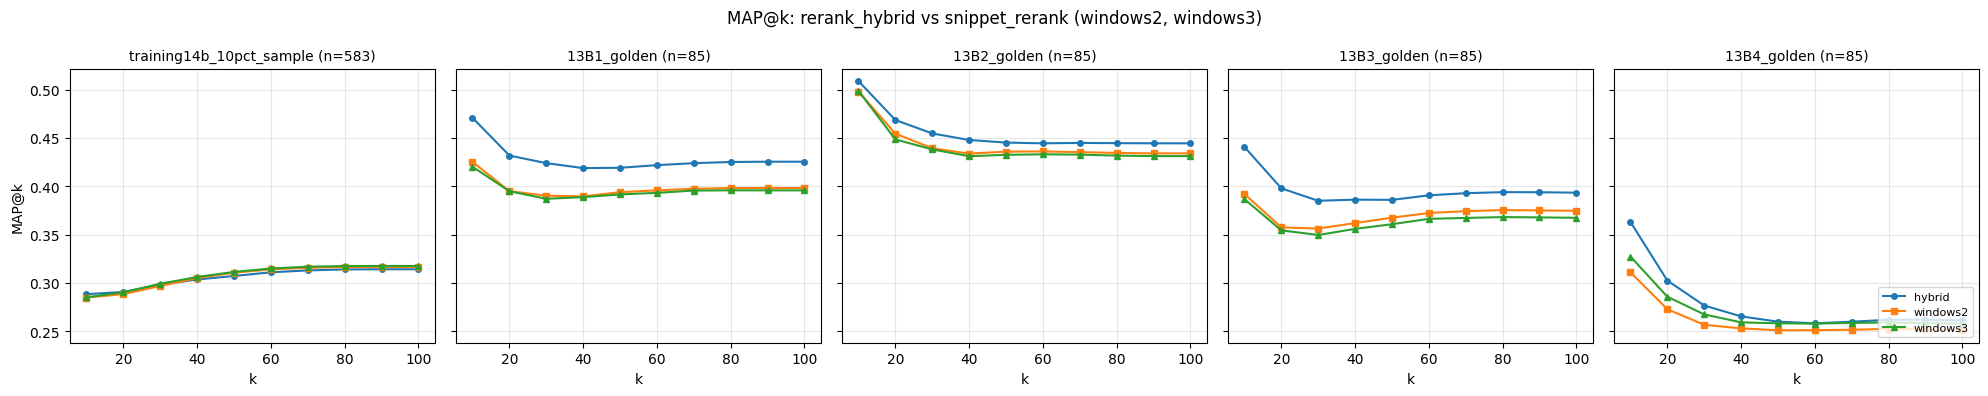

In [132]:
# MAP@k curves (k = 10..100 step 10), one subplot per split — hybrid, windows2, windows3
fig, axes = plt.subplots(1, len(SPLITS), figsize=(4 * len(SPLITS), 4), sharey=True)
if len(SPLITS) == 1:
    axes = [axes]

markers = {"hybrid": "o", "windows2": "s", "windows3": "^"}
for ax, (split_label, _) in zip(axes, SPLITS):
    gold = split_gold.get(split_label, {})
    h_rm = hybrid_runs.get(split_label, {})
    if not gold:
        continue
    h_map = compute_map_at_ks(gold, h_rm, KS)
    ax.plot(KS, [h_map[k] for k in KS], "o-", label="hybrid", markersize=4)
    for sl in SNIPPET_LABELS:
        s_rm = snippet_runs.get(sl, {}).get(split_label, {})
        s_map = compute_map_at_ks(gold, s_rm, KS)
        ax.plot(KS, [s_map[k] for k in KS], f"{markers.get(sl, 'x')}-", label=sl, markersize=4)
    n_q = split_n.get(split_label, 0)
    ax.set_title(f"{split_label} (n={n_q})", fontsize=10)
    ax.set_xlabel("k")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("MAP@k")
axes[-1].legend(loc="lower right", fontsize=8)
fig.suptitle("MAP@k: rerank_hybrid vs snippet_rerank (windows2, windows3)", fontsize=12)
fig.tight_layout()
plt.show()

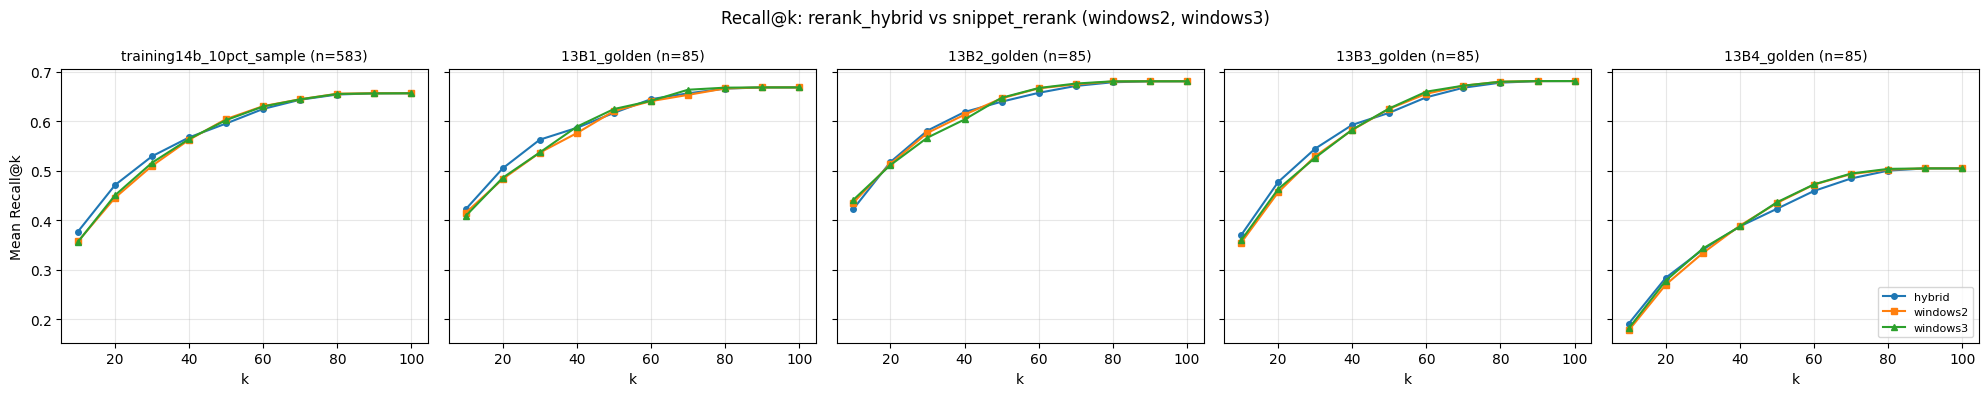

In [133]:
# Recall@k curves (k = 10..100 step 10), one subplot per split — hybrid, windows2, windows3
def mean_recall_at_ks(gold_map, run_map, ks):
    qids = [q for q in gold_map if q in run_map and gold_map[q]]
    if not qids:
        return {k: 0.0 for k in ks}
    return {
        k: float(np.mean([recall_at_k(set(gold_map[q]), run_map[q], k) for q in qids]))
        for k in ks
    }

fig, axes = plt.subplots(1, len(SPLITS), figsize=(4 * len(SPLITS), 4), sharey=True)
if len(SPLITS) == 1:
    axes = [axes]

markers = {"hybrid": "o", "windows2": "s", "windows3": "^"}
for ax, (split_label, _) in zip(axes, SPLITS):
    gold = split_gold.get(split_label, {})
    h_rm = hybrid_runs.get(split_label, {})
    if not gold:
        continue
    h_rec = mean_recall_at_ks(gold, h_rm, KS)
    ax.plot(KS, [h_rec[k] for k in KS], "o-", label="hybrid", markersize=4)
    for sl in SNIPPET_LABELS:
        s_rm = snippet_runs.get(sl, {}).get(split_label, {})
        s_rec = mean_recall_at_ks(gold, s_rm, KS)
        ax.plot(KS, [s_rec[k] for k in KS], f"{markers.get(sl, 'x')}-", label=sl, markersize=4)
    n_q = split_n.get(split_label, 0)
    ax.set_title(f"{split_label} (n={n_q})", fontsize=10)
    ax.set_xlabel("k")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Mean Recall@k")
axes[-1].legend(loc="lower right", fontsize=8)
fig.suptitle("Recall@k: rerank_hybrid vs snippet_rerank (windows2, windows3)", fontsize=12)
fig.tight_layout()
plt.show()

In [134]:
# Per-query win/loss: better/worse/tied AP@10 with snippet (windows2, windows3) vs hybrid
wl_rows = []
for split_label, _ in SPLITS:
    gold = split_gold.get(split_label, {})
    h_rm = hybrid_runs.get(split_label, {})
    if not gold:
        continue
    for sl in SNIPPET_LABELS:
        s_rm = snippet_runs.get(sl, {}).get(split_label, {})
        qids = [q for q in gold if q in h_rm and q in s_rm and gold[q]]
        deltas = []
        for q in qids:
            g = set(gold[q])
            h_ap = ap_at_k(g, h_rm[q], k=10)
            s_ap = ap_at_k(g, s_rm[q], k=10)
            deltas.append(s_ap - h_ap)

        deltas = np.array(deltas)
        n = len(deltas)
        better = deltas > 0
        worse = deltas < 0
        tied = deltas == 0

        wl_rows.append({
            "split": split_label,
            "snippet": sl,
            "n_queries": n,
            "better": int(better.sum()),
            "worse": int(worse.sum()),
            "tied": int(tied.sum()),
            "better %": f"{100 * better.mean():.1f}%",
            "worse %": f"{100 * worse.mean():.1f}%",
            "tied %": f"{100 * tied.mean():.1f}%",
            "mean d(better)": f"+{deltas[better].mean():.4f}" if better.any() else "-",
            "mean d(worse)": f"{deltas[worse].mean():.4f}" if worse.any() else "-",
            "mean d(all)": f"{deltas.mean():+.4f}",
        })

pd.DataFrame(wl_rows)

,split,snippet,n_queries,better,worse,tied,better %,worse %,tied %,mean d(better),mean d(worse),mean d(all)
0,training14b_10pct_sample,windows2,583,152,231,200,26.1%,39.6%,34.3%,+0.1505,-0.1079,-0.0035
1,training14b_10pct_sample,windows3,583,153,231,199,26.2%,39.6%,34.1%,+0.1404,-0.1010,-0.0032
2,13B1_golden,windows2,85,23,38,24,27.1%,44.7%,28.2%,+0.1207,-0.1750,-0.0456
3,13B1_golden,windows3,85,24,38,23,28.2%,44.7%,27.1%,+0.0958,-0.1737,-0.0506
4,13B2_golden,windows2,85,33,35,17,38.8%,41.2%,20.0%,+0.1408,-0.1591,-0.0109
5,13B2_golden,windows3,85,36,31,18,42.4%,36.5%,21.2%,+0.1353,-0.1849,-0.0102
6,13B3_golden,windows2,85,28,44,13,32.9%,51.8%,15.3%,+0.1022,-0.1593,-0.0488
7,13B3_golden,windows3,85,30,39,16,35.3%,45.9%,18.8%,+0.0814,-0.1803,-0.0540
8,13B4_golden,windows2,85,26,48,11,30.6%,56.5%,12.9%,+0.0740,-0.1324,-0.0521
9,13B4_golden,windows3,85,30,42,13,35.3%,49.4%,15.3%,+0.0879,-0.1352,-0.0358


In [135]:
# RRF fusion: union of top RUN_TOP from hybrid + snippet; weighted RRF; return top OUTPUT_TOP
def rrf_fuse_top10(hybrid_docs: list, snippet_docs: list, k: int, w_hybrid: float, w_snippet: float) -> list:
    hybrid_top = hybrid_docs[:RUN_TOP]
    snippet_top = snippet_docs[:RUN_TOP]
    rank_hybrid = {str(d): i + 1 for i, d in enumerate(hybrid_top)}
    rank_snippet = {str(d): i + 1 for i, d in enumerate(snippet_top)}
    union = list(dict.fromkeys(hybrid_top + snippet_top))
    scores = []
    for d in union:
        ds = str(d)
        s = 0.0
        if ds in rank_hybrid:
            s += w_hybrid / (k + rank_hybrid[ds])
        if ds in rank_snippet:
            s += w_snippet / (k + rank_snippet[ds])
        scores.append((ds, s))
    # Primary: RRF score desc. Secondary: docno asc so tie-break is neutral (not hybrid-first from union order)
    scores.sort(key=lambda x: (-x[1], x[0]))
    return [d for d, _ in scores[:OUTPUT_TOP]]

rrf_rows = []
for split_label, _ in SPLITS:
    gold = split_gold.get(split_label, {})
    h_rm = hybrid_runs.get(split_label, {})
    if not gold:
        continue
    for sl in SNIPPET_LABELS:
        s_rm = snippet_runs.get(sl, {}).get(split_label, {})
        qids = [q for q in gold if q in h_rm and q in s_rm and gold[q]]
        if not qids:
            continue
        for k in RRF_KS:
            for w_hybrid, w_snippet in RRF_WEIGHTS:
                ap10_list = [
                    ap_at_k(set(gold[q]), rrf_fuse_top10(h_rm[q], s_rm[q], k, w_hybrid, w_snippet), k=OUTPUT_TOP)
                    for q in qids
                ]
                rrf_rows.append({
                    "split": split_label,
                    "snippet_label": sl,
                    "k": k,
                    "w_hybrid": w_hybrid,
                    "w_snippet": w_snippet,
                    "MAP@10": float(np.mean(ap10_list)),
                    "n_queries": len(qids),
                })

# Sweep once with all four test batches merged, for each snippet source
TEST_SPLITS = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]
gold_merged = {}
h_merged = {}
for spl in TEST_SPLITS:
    gold_merged.update(split_gold.get(spl, {}))
    h_merged.update(hybrid_runs.get(spl, {}))
for sl in SNIPPET_LABELS:
    s_merged = {}
    for spl in TEST_SPLITS:
        s_merged.update(snippet_runs.get(sl, {}).get(spl, {}))
    qids_merged = [q for q in gold_merged if q in h_merged and q in s_merged and gold_merged[q]]
    for k in RRF_KS:
        for w_hybrid, w_snippet in RRF_WEIGHTS:
            ap10_list = [
                ap_at_k(set(gold_merged[q]), rrf_fuse_top10(h_merged[q], s_merged[q], k, w_hybrid, w_snippet), k=OUTPUT_TOP)
                for q in qids_merged
            ]
            rrf_rows.append({
                "split": "test_merged",
                "snippet_label": sl,
                "k": k,
                "w_hybrid": w_hybrid,
                "w_snippet": w_snippet,
                "MAP@10": float(np.mean(ap10_list)),
                "n_queries": len(qids_merged),
            })

rrf_results = pd.DataFrame(rrf_rows)
rrf_results["weight_label"] = rrf_results.apply(
    lambda r: f"({r['w_hybrid']:.3f},{r['w_snippet']:.3f})", axis=1
)
weight_labels = [f"({w[0]:.3f},{w[1]:.3f})" for w in RRF_WEIGHTS]
assert len(weight_labels) == len(set(weight_labels)), "Duplicate weight labels would break pivot/plot"
print("RRF fusion: MAP@10 per (split, snippet_label, k, weights). test_merged = all four test batches (13B1–13B4) combined.")
display(rrf_results)

# Pivot per split: rows = (k, snippet_label), columns = weight config (windows2 and windows3 together)
for split_label in rrf_results["split"].unique():
    grp = rrf_results[rrf_results["split"] == split_label]
    pivot = grp.pivot_table(index=["k", "snippet_label"], columns="weight_label", values="MAP@10", aggfunc="first")
    pivot = pivot.reindex(weight_labels, axis=1)
    # n per snippet within this split (for display)
    n_by_snip = grp.groupby("snippet_label")["n_queries"].max().to_dict()
    n_info = ", ".join(f"{sl}: n={n_by_snip.get(sl, 0)}" for sl in SNIPPET_LABELS if sl in n_by_snip)
    print(f"\n{split_label} [{n_info}]")
    display(pivot)

RRF fusion: MAP@10 per (split, snippet_label, k, weights). test_merged = all four test batches (13B1–13B4) combined.


,split,snippet_label,k,w_hybrid,w_snippet,MAP@10,n_queries,weight_label
0,training14b_10pct_sample,windows2,60,1.0,0.0,0.288364,583,"(1.000,0.000)"
1,training14b_10pct_sample,windows2,60,0.9,0.1,0.289375,583,"(0.900,0.100)"
2,training14b_10pct_sample,windows2,60,0.8,0.2,0.288710,583,"(0.800,0.200)"
3,training14b_10pct_sample,windows2,60,0.7,0.3,0.293060,583,"(0.700,0.300)"
4,training14b_10pct_sample,windows2,60,0.6,0.4,0.291480,583,"(0.600,0.400)"
...,...,...,...,...,...,...,...,...
67,test_merged,windows3,60,0.9,0.1,0.447407,340,"(0.900,0.100)"
68,test_merged,windows3,60,0.8,0.2,0.449031,340,"(0.800,0.200)"
69,test_merged,windows3,60,0.7,0.3,0.448440,340,"(0.700,0.300)"
70,test_merged,windows3,60,0.6,0.4,0.448365,340,"(0.600,0.400)"



training14b_10pct_sample [windows2: n=583, windows3: n=583]


weight_label      (1.000,0.000)  (0.900,0.100)  (0.800,0.200)  (0.700,0.300)  \
k  snippet_label                                                               
60 windows2            0.288364       0.289375       0.288710       0.293060   
   windows3            0.288364       0.288573       0.288978       0.293341   

weight_label      (0.600,0.400)  (0.500,0.500)  
k  snippet_label                                
60 windows2            0.291480       0.294951  
   windows3            0.293346       0.293907


13B1_golden [windows2: n=85, windows3: n=85]


...

weight_label      (1.000,0.000)  (0.900,0.100)  (0.800,0.200)  (0.700,0.300)  \
k  snippet_label                                                               
60 windows2            0.440677       0.443430       0.440453       0.440198   
   windows3            0.440677       0.444892       0.446900       0.448128   

weight_label      (0.600,0.400)  (0.500,0.500)  
k  snippet_label                                
60 windows2            0.443541       0.443295  
   windows3            0.441124       0.442639


13B4_golden [windows2: n=85, windows3: n=85]


weight_label      (1.000,0.000)  (0.900,0.100)  (0.800,0.200)  (0.700,0.300)  \
k  snippet_label                                                               
60 windows2            0.363099       0.361134       0.360964       0.356634   
   windows3            0.363099       0.360279       0.363144       0.357263   

weight_label      (0.600,0.400)  (0.500,0.500)  
k  snippet_label                                
60 windows2            0.348084       0.345366  
   windows3            0.353377       0.352386


test_merged [windows2: n=340, windows3: n=340]


weight_label      (1.000,0.000)  (0.900,0.100)  (0.800,0.200)  (0.700,0.300)  \
k  snippet_label                                                               
60 windows2            0.445862       0.448123       0.449619       0.448563   
   windows3            0.445862       0.447407       0.449031       0.448440   

weight_label      (0.600,0.400)  (0.500,0.500)  
k  snippet_label                                
60 windows2            0.447545       0.445579  
   windows3            0.448365       0.447522

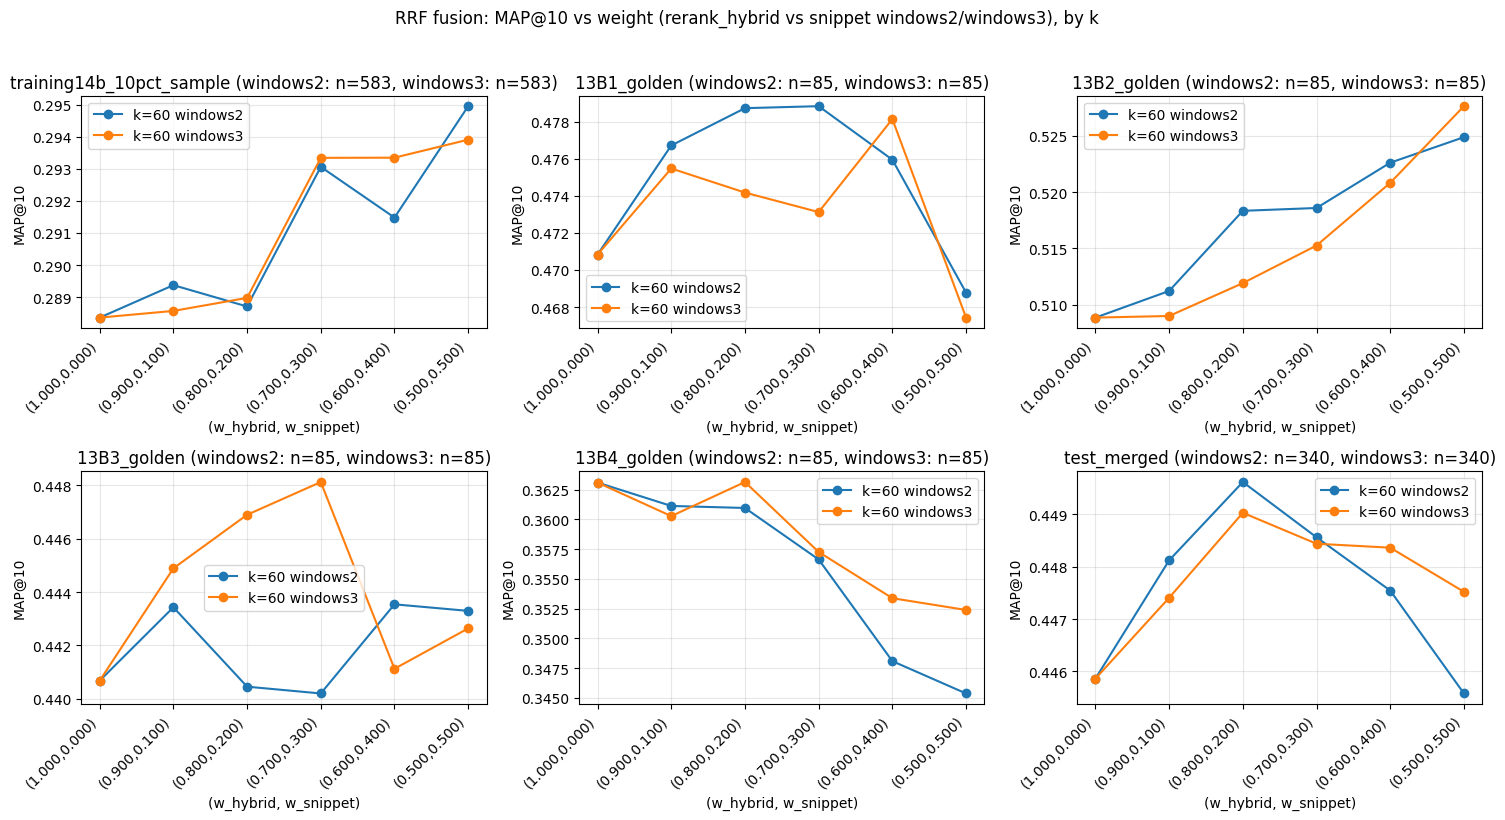

In [136]:
# Line plot: MAP@10 vs weight config — one line per (k, snippet_label), one panel per split
weight_order = [f"({w[0]:.3f},{w[1]:.3f})" for w in RRF_WEIGHTS]
n_splits = rrf_results.groupby("split").ngroups
n_cols = min(3, n_splits)
n_rows = (n_splits + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
if n_splits == 1:
    axes = np.array([axes])
axes = axes.flat
for ax, (split_label, grp) in zip(axes, rrf_results.groupby("split", sort=False)):
    for k in RRF_KS:
        for sl in SNIPPET_LABELS:
            sub_grp = grp[(grp["k"] == k) & (grp["snippet_label"] == sl)]
            sub = sub_grp.set_index("weight_label").reindex(weight_order)
            vals = sub["MAP@10"].values
            ax.plot(range(len(weight_order)), vals, marker="o", label=f"k={k} {sl}", markersize=6)
    ax.set_xticks(range(len(weight_order)))
    ax.set_xticklabels(weight_order, rotation=45, ha="right")
    # n per snippet within this split for title
    n_by_snip = grp.groupby("snippet_label")["n_queries"].max().to_dict()
    n_info = ", ".join(f"{sl}: n={n_by_snip.get(sl, 0)}" for sl in SNIPPET_LABELS if sl in n_by_snip)
    ax.set_ylabel("MAP@10")
    ax.set_xlabel("(w_hybrid, w_snippet)")
    ax.set_title(f"{split_label} ({n_info})")
    ax.legend()
    ax.grid(True, alpha=0.3)
for j in range(n_splits, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("RRF fusion: MAP@10 vs weight (rerank_hybrid vs snippet windows2/windows3), by k", y=1.02)
plt.tight_layout()
plt.show()

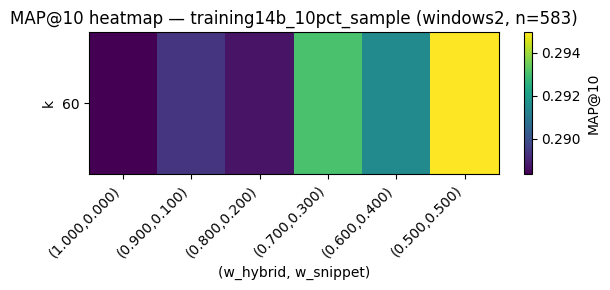

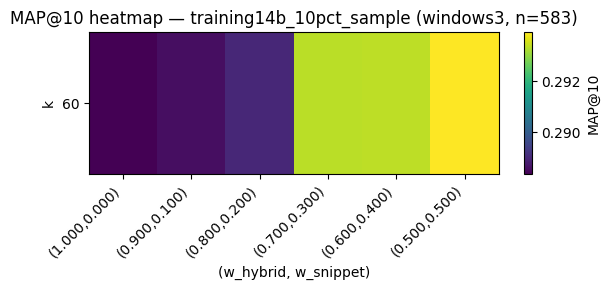

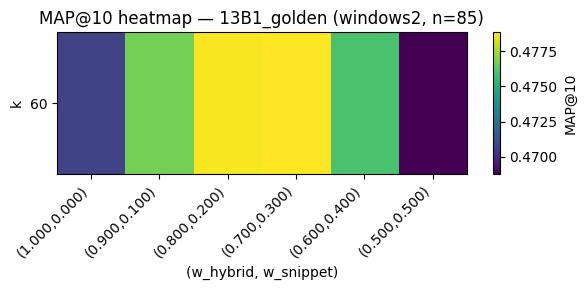

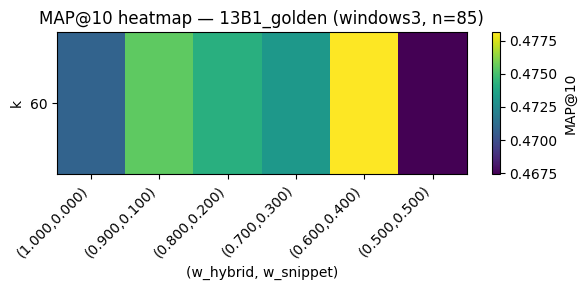

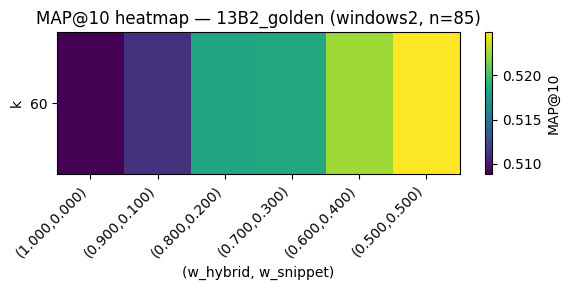

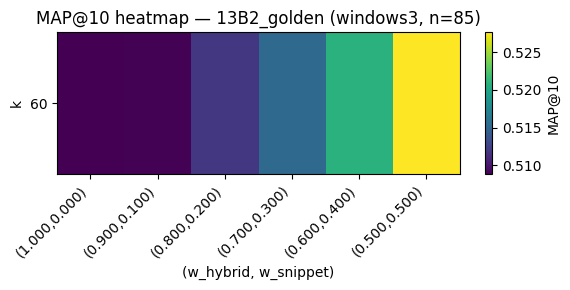

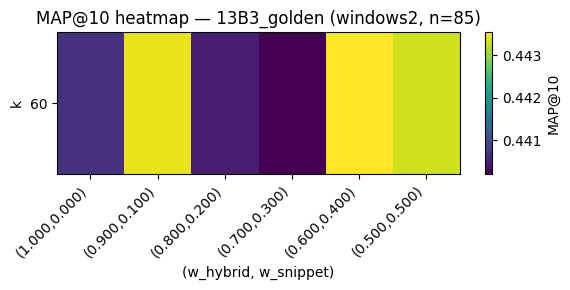

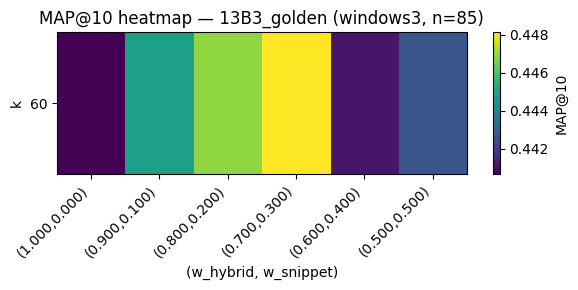

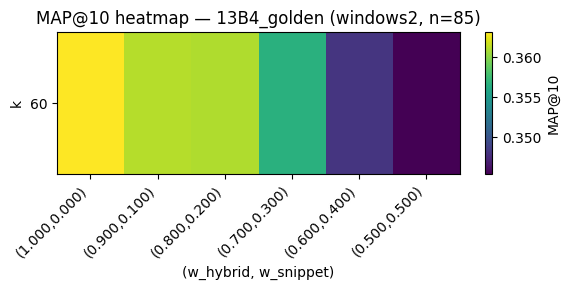

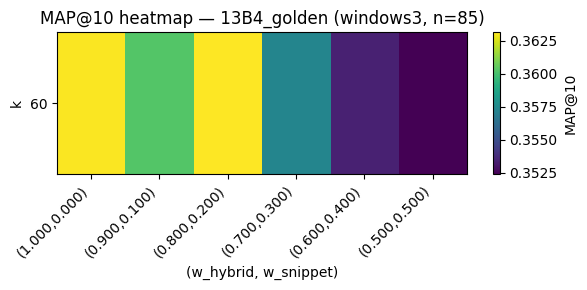

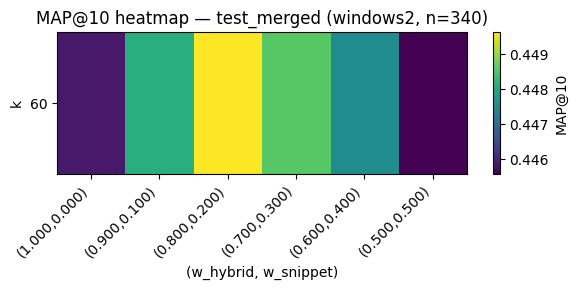

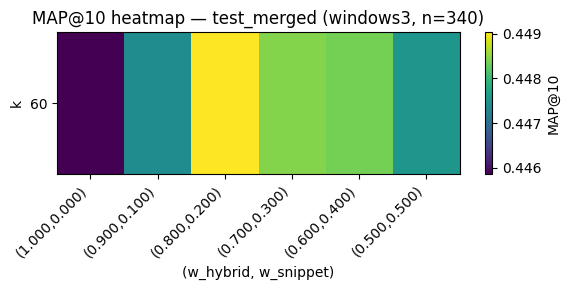

In [137]:
# Heatmap per (split, snippet_label): rows = k, columns = (w_hybrid, w_snippet), color = MAP@10
weight_order = [f"({w[0]:.3f},{w[1]:.3f})" for w in RRF_WEIGHTS]
for (split_label, sl), grp in rrf_results.groupby(["split", "snippet_label"], sort=False):
    pivot = grp.pivot_table(index="k", columns="weight_label", values="MAP@10", aggfunc="first")
    pivot = pivot.reindex(index=RRF_KS, columns=weight_order)
    fig, ax = plt.subplots(figsize=(6, 3))
    im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(weight_order)))
    ax.set_xticklabels(weight_order, rotation=45, ha="right")
    ax.set_yticks(range(len(RRF_KS)))
    ax.set_yticklabels(RRF_KS)
    ax.set_xlabel("(w_hybrid, w_snippet)")
    ax.set_ylabel("k")
    n_q = grp["n_queries"].iloc[0] if not grp.empty else 0
    ax.set_title(f"MAP@10 heatmap — {split_label} ({sl}, n={n_q})")
    plt.colorbar(im, ax=ax, label="MAP@10")
    plt.tight_layout()
    plt.show()

window3, 0.8,0.2